# Bollinger Bands — AAPL

Middle band = 20-day SMA of close. Upper/lower = middle ± 2 × 20-day rolling std.

- **%B** = (close − lower) / (upper − lower): where price sits inside the bands (0 = lower, 1 = upper).
- **Bandwidth** = (upper − lower) / middle: volatility squeeze/expansion.

In [1]:
import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
ticker = "AAPL"
start_date = datetime.date(2023, 1, 1)
end_date = datetime.date.today()

window = 20      # SMA / std lookback
num_std = 2      # band width in standard deviations

## Download prices

In [3]:
df = yf.download(ticker, start_date, end_date, auto_adjust=True)
df.columns = df.columns.get_level_values(0)  # flatten (field, ticker) MultiIndex
prices = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
prices.tail()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100
2026-09-09,315.489990,319.149994,309.899994,315.339996,65640000
2026-09-10,316.670013,326.739990,316.510010,326.570007,70011900
2026-09-11,327.450012,336.220001,326.299988,332.269989,50716900
2026-09-14,334.790009,335.500000,331.339996,333.079987,39269100


## Compute the bands

In [4]:
def bollinger_bands(close: pd.Series, window: int = 20, num_std: float = 2) -> pd.DataFrame:
    mid = close.rolling(window).mean()
    std = close.rolling(window).std(ddof=0)
    upper = mid + num_std * std
    lower = mid - num_std * std
    return pd.DataFrame({
        "close": close,
        "bb_mid": mid,
        "bb_upper": upper,
        "bb_lower": lower,
        "pct_b": (close - lower) / (upper - lower),
        "bandwidth": (upper - lower) / mid,
    })


bb = bollinger_bands(prices["Close"], window, num_std).dropna()
bb.tail()

,close,bb_mid,bb_upper,bb_lower,pct_b,bandwidth
Date,,,,,,
2026-09-08,316.220001,313.537999,327.955303,299.120695,0.593013,0.091965
2026-09-09,315.339996,314.059499,327.935081,300.183916,0.546142,0.088363
2026-09-10,326.570007,315.275499,329.060523,301.490475,0.909666,0.087447
2026-09-11,332.269989,316.625998,331.472951,301.779045,1.026842,0.093782
2026-09-14,333.079987,317.983498,333.614449,302.352546,0.982904,0.098313


In [5]:
# simple mean-reversion signals: close outside the bands
bb["signal"] = 0
bb.loc[bb["close"] < bb["bb_lower"], "signal"] = 1    # oversold -> buy
bb.loc[bb["close"] > bb["bb_upper"], "signal"] = -1   # overbought -> sell
bb["signal"].value_counts()

signal
 0    798
-1     70
 1     40
Name: count, dtype: int64

## Plot

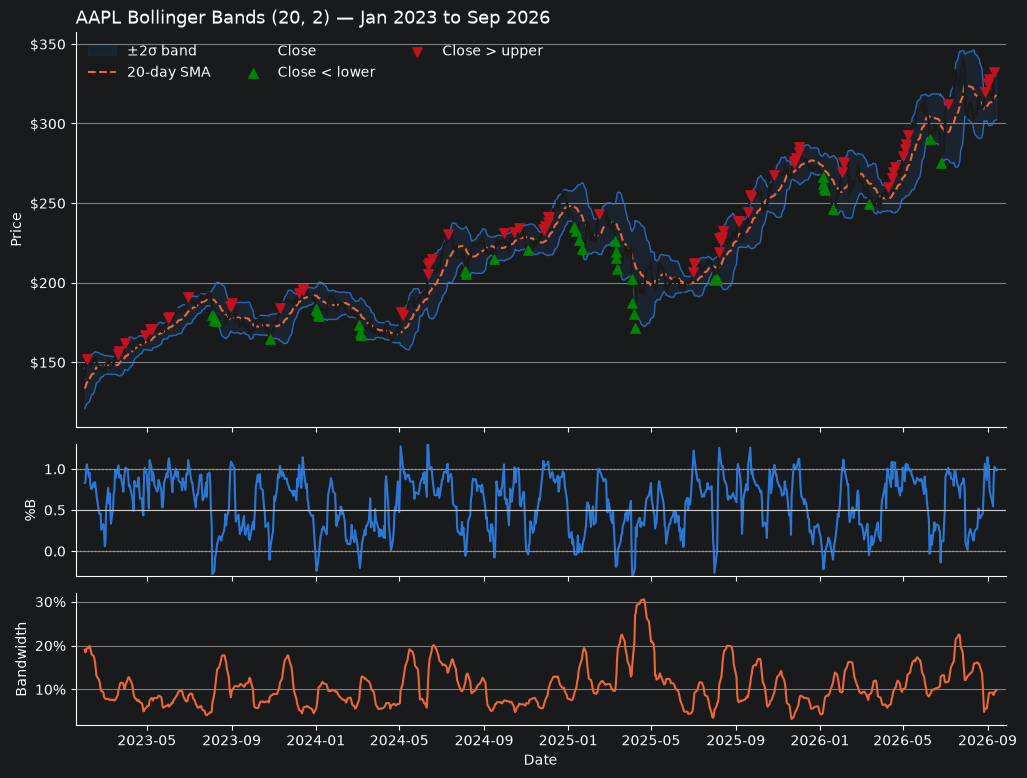

In [6]:
c_price, c_band, c_mid = "#1a1a19", "#2a78d6", "#eb6834"

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(12, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1], "hspace": 0.08}
)

# --- price + bands ---
ax1.fill_between(bb.index, bb["bb_lower"], bb["bb_upper"], color=c_band, alpha=0.10, label=f"±{num_std}σ band")
ax1.plot(bb.index, bb["bb_upper"], color=c_band, linewidth=1, alpha=0.8)
ax1.plot(bb.index, bb["bb_lower"], color=c_band, linewidth=1, alpha=0.8)
ax1.plot(bb.index, bb["bb_mid"], color=c_mid, linewidth=1.5, linestyle="--", label=f"{window}-day SMA")
ax1.plot(bb.index, bb["close"], color=c_price, linewidth=1.8, label="Close")

buys, sells = bb[bb["signal"] == 1], bb[bb["signal"] == -1]
ax1.scatter(buys.index, buys["close"], marker="^", s=45, color="#008300", zorder=3, label="Close < lower")
ax1.scatter(sells.index, sells["close"], marker="v", s=45, color="#c1121f", zorder=3, label="Close > upper")

ax1.set_title(f"{ticker} Bollinger Bands ({window}, {num_std}) — {bb.index[0]:%b %Y} to {bb.index[-1]:%b %Y}",
              fontsize=13, loc="left")
ax1.set_ylabel("Price")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax1.legend(loc="upper left", frameon=False, ncol=3)

# --- %B ---
ax2.plot(bb.index, bb["pct_b"], color=c_band, linewidth=1.5)
ax2.axhline(1, color="#999999", linewidth=1, linestyle=":")
ax2.axhline(0, color="#999999", linewidth=1, linestyle=":")
ax2.axhline(0.5, color="#cccccc", linewidth=0.8)
ax2.set_ylabel("%B")
ax2.set_ylim(-0.3, 1.3)

# --- bandwidth ---
ax3.plot(bb.index, bb["bandwidth"], color=c_mid, linewidth=1.5)
ax3.set_ylabel("Bandwidth")
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax3.set_xlabel("Date")

for ax in (ax1, ax2, ax3):
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.01)

plt.show()